# 🏆 06 - Tüm Modellerin Karşılaştırılması ve Raporlama
## Uydu Telemetri Anomali Tespiti - Bitirme Projesi Nihai Raporu

**Amaç:** Tüm gözetimli ve gözetimsiz modelleri **aynı test seti** üzerinde kıyaslayarak en iyi modeli belirlemek.

> **Not:** Bu notebook, `train_all_models.py` tarafından kaydedilen test verisi ve scaler'ı doğrudan yükler. Böylece tüm modeller birebir aynı veri üzerinde değerlendirilir.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings, time, joblib, os

from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Kütüphaneler yüklendi.')


✅ Kütüphaneler yüklendi.


---
## 📥 Bölüm 1: Kaydedilmiş Test Verisi ve Modelleri Yükle


In [11]:
# Tutarlı test verisini yükle (04 numaralı defter tarafından kaydedildi)
test_data = joblib.load('../models/test_data.joblib')
X_test = test_data['X_test']
y_test = test_data['y_test']
print(f"Test Seti: {X_test.shape}, Anomali Oranı: {y_test.mean():.3f}")

# Sıralı (sequence) Keras modelleri 3B girdi bekler: (örnek, özellik, 1)
SEQUENCE_MODELS = {'LSTM', 'BiLSTM', 'GRU', 'BiGRU', 'CNN1D', 'CNN_LSTM', 'CNN_BiLSTM',
                   'CNN_GRU', 'Transformer', 'TCN', 'Attention_BiLSTM',
                   'FCN', 'ResNet1D', 'InceptionTime', 'LSTM_FCN'}
# Tek tip API'li PyOD dedektörleri (decision_function + predict)
PYOD_MODELS = {'ECOD', 'COPOD', 'HBOS', 'CBLOF'}

# ── Gözetimli: klasik / boosting / ensemble (joblib) ──
models = {}
joblib_models = [
    ('RandomForest', '../models/rf_model.joblib'), ('XGBoost', '../models/xgb_model.joblib'),
    ('SVM', '../models/svm_model.joblib'), ('LightGBM', '../models/lightgbm_model.joblib'),
    ('CatBoost', '../models/catboost_model.joblib'), ('Stacking Ensemble', '../models/stacking_ensemble_model.joblib'),
    ('ExtraTrees', '../models/extratrees_model.joblib'), ('GradientBoosting', '../models/gradientboosting_model.joblib'),
    ('HistGradientBoosting', '../models/histgradientboosting_model.joblib'), ('AdaBoost', '../models/adaboost_model.joblib'),
    ('KNN', '../models/knn_model.joblib'), ('LogisticRegression', '../models/logisticregression_model.joblib'),
    ('DecisionTree', '../models/decisiontree_model.joblib'), ('NaiveBayes', '../models/naivebayes_model.joblib'),
    ('Voting Ensemble', '../models/voting_ensemble_model.joblib'), ('LDA', '../models/lda_model.joblib'),
    ('QDA', '../models/qda_model.joblib'), ('Bagging', '../models/bagging_model.joblib'),
    ('Ridge', '../models/ridge_model.joblib'), ('SGD', '../models/sgd_model.joblib'),
]
for name, path in joblib_models:
    if os.path.exists(path):
        models[name] = joblib.load(path)

# ── Gözetimli: Keras (MLP + derin sıralı/hibrit ağlar) ──
def _kload(path):
    from tensorflow.keras.models import load_model
    return load_model(path, compile=False, safe_mode=False)

try:
    keras_models = [
        ('MLP', '../models/mlp_model.keras'), ('LSTM', '../models/lstm_model.keras'),
        ('BiLSTM', '../models/bilstm_model.keras'), ('GRU', '../models/gru_model.keras'),
        ('BiGRU', '../models/bigru_model.keras'), ('CNN1D', '../models/cnn1d_model.keras'),
        ('CNN_LSTM', '../models/cnn_lstm_model.keras'), ('CNN_BiLSTM', '../models/cnn_bilstm_model.keras'),
        ('CNN_GRU', '../models/cnn_gru_model.keras'), ('Transformer', '../models/transformer_model.keras'),
        ('TCN', '../models/tcn_model.keras'), ('Attention_BiLSTM', '../models/attention_bilstm_model.keras'),
        ('FCN', '../models/fcn_model.keras'), ('ResNet1D', '../models/resnet1d_model.keras'),
        ('InceptionTime', '../models/inceptiontime_model.keras'), ('LSTM_FCN', '../models/lstm_fcn_model.keras'),
    ]
    for name, path in keras_models:
        if os.path.exists(path):
            models[name] = _kload(path)
except Exception as e:
    print(f"⚠️ Gözetimli Keras modelleri yüklenemedi: {e}")

# ── Gözetimsiz modeller (joblib) ──
unsup_dir = '../models/unsupervised/'
for name, fname in [('IsolationForest', 'isolationforest_model.joblib'), ('OneClassSVM', 'oneclasssvm_model.joblib'),
                    ('KMeans', 'kmeans_model.joblib'), ('LOF', 'lof_model.joblib'),
                    ('GMM', 'gmm_model.joblib'), ('EllipticEnvelope', 'ellipticenvelope_model.joblib'),
                    ('PCA', 'pca_model.joblib'), ('DBSCAN', 'dbscan_model.joblib'),
                    ('ECOD', 'ecod_model.joblib'), ('COPOD', 'copod_model.joblib'),
                    ('HBOS', 'hbos_model.joblib'), ('CBLOF', 'cblof_model.joblib')]:
    full = os.path.join(unsup_dir, fname)
    if os.path.exists(full):
        models[name] = joblib.load(full)

# ── Gözetimsiz: Keras (Autoencoder, VAE) ──
try:
    for name, fname in [('Autoencoder', 'autoencoder_model.keras'), ('VAE', 'vae_model.keras')]:
        full = os.path.join(unsup_dir, fname)
        if os.path.exists(full):
            models[name] = _kload(full)
except Exception as e:
    print(f"⚠️ Gözetimsiz Keras modelleri yüklenemedi: {e}")

# Gözetimsiz eşik değerleri
thresholds = {}
tp = os.path.join(unsup_dir, 'unsupervised_thresholds.json')
if os.path.exists(tp):
    with open(tp) as f:
        thresholds = json.load(f)

print(f"✅ Yüklenen toplam model sayısı: {len(models)}")
print('   ' + ', '.join(models.keys()))

Task was destroyed but it is pending!
task: <Task pending name='Task-96' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-97' coro=<Kernel.shell_main() running at /home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-97' coro=<Kernel.shell_main() running at /home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Test Seti: (425, 24), Anomali Oranı: 0.205
⚠️ Gözetimsiz Keras modelleri yüklenemedi: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': None}.

Exception encountered: Could not locate class 'SamplingLayer'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'src.models.unsupervised', 'class_name': 'SamplingLayer', 'config': {'name': 'z', 'beta': 1.0, 'trainable': True, 'dtype': {'module': 'keras

---
## 📋 Bölüm 2: Tüm Modellerin Metrik Hesaplaması


In [12]:
all_metrics = {}
predictions = {}
probabilities = {}

# Sıralı modeller için 3B tensör (örnek, özellik, 1)
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

for name, model in models.items():
    start = time.time()
    if name in SEQUENCE_MODELS:
        prob = model.predict(X_test_seq, verbose=0).flatten()
        pred = (prob >= 0.5).astype(int)
    elif name == 'MLP':
        prob = model.predict(X_test, verbose=0).flatten()
        pred = (prob >= 0.5).astype(int)
    elif name in PYOD_MODELS:
        prob = model.decision_function(X_test)
        pred = model.predict(X_test)
    elif name in ('Autoencoder', 'VAE'):
        recon = model.predict(X_test, verbose=0)
        prob = np.mean(np.power(X_test - recon, 2), axis=1)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'PCA':
        recon = model.inverse_transform(model.transform(X_test))
        prob = np.mean(np.power(X_test - recon, 2), axis=1)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name in ('IsolationForest', 'LOF'):
        prob = -model.score_samples(X_test)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name in ('GMM', 'EllipticEnvelope'):
        prob = -model.score_samples(X_test)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'OneClassSVM':
        prob = -model.decision_function(X_test)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'KMeans':
        prob = np.min(model.transform(X_test), axis=1)
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif name == 'DBSCAN':
        prob = model.kneighbors(X_test)[0].ravel()  # en yakın çekirdek noktaya uzaklık
        pred = (prob > thresholds.get(name, 0)).astype(int)
    elif hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test)[:, 1]
        pred = model.predict(X_test)
    elif hasattr(model, 'decision_function'):
        prob = model.decision_function(X_test)  # Ridge gibi modeller
        pred = model.predict(X_test)
    else:
        pred = model.predict(X_test)
        prob = pred.astype(float)

    inf_time = (time.time() - start) * 1000 / len(X_test)
    predictions[name] = pred
    probabilities[name] = prob

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    try: auc_val = roc_auc_score(y_test, prob)
    except: auc_val = 0.5
    tn,fp,fn,tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    far = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0

    all_metrics[name] = {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'AUC-ROC':auc_val,'FAR':far,'FNR':fnr,'Inf.Time(ms)':inf_time}

df_metrics = pd.DataFrame(all_metrics).T.sort_values('F1', ascending=False)
print(f"📊 Karşılaştırılan model sayısı: {len(df_metrics)}")
display(df_metrics.style.background_gradient(cmap='YlGnBu', subset=['Accuracy','F1','AUC-ROC']).format('{:.4f}'))

📊 Karşılaştırılan model sayısı: 49


,Accuracy,Precision,Recall,F1,AUC-ROC,FAR,FNR,Inf.Time(ms)
BiGRU,0.9506,0.8438,0.9310,0.8852,0.9896,0.0444,0.0690,1.2979
MLP,0.9529,0.8851,0.8851,0.8851,0.9840,0.0296,0.1149,0.3327
XGBoost,0.9529,0.9136,0.8506,0.8810,0.9829,0.0207,0.1494,0.0069
CNN_GRU,0.9506,0.8750,0.8851,0.8800,0.9766,0.0325,0.1149,0.8376
Voting Ensemble,0.9482,0.8652,0.8851,0.8750,0.9846,0.0355,0.1149,0.1747
ResNet1D,0.9506,0.9231,0.8276,0.8727,0.9819,0.0178,0.1724,0.9323
HistGradientBoosting,0.9506,0.9231,0.8276,0.8727,0.9893,0.0178,0.1724,0.1760
Bagging,0.9482,0.8916,0.8506,0.8706,0.9799,0.0266,0.1494,5.7657
FCN,0.9506,0.9459,0.8046,0.8696,0.9707,0.0118,0.1954,0.3292
CNN1D,0.9482,0.9114,0.8276,0.8675,0.9820,0.0207,0.1724,0.3450


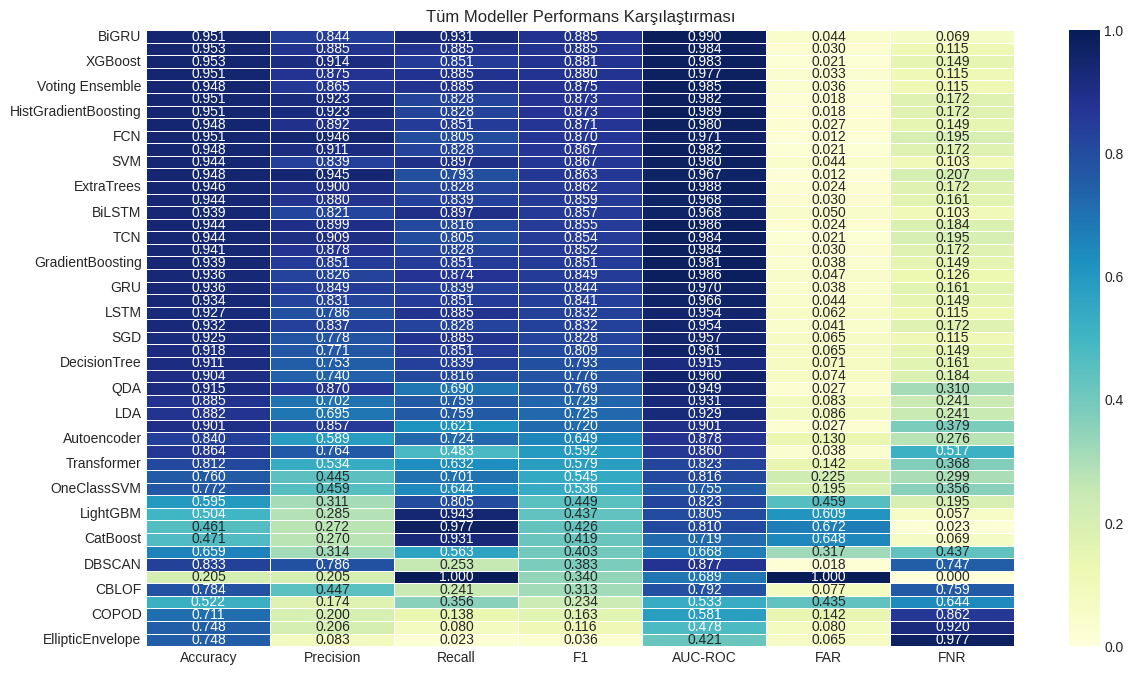

In [13]:
perf_cols = ['Accuracy','Precision','Recall','F1','AUC-ROC','FAR','FNR']
plt.figure(figsize=(14, 8))
sns.heatmap(df_metrics[perf_cols], annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title('Tüm Modeller Performans Karşılaştırması')
plt.savefig('../reports/figures/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 📈 Bölüm 3: ROC ve PR Eğrileri


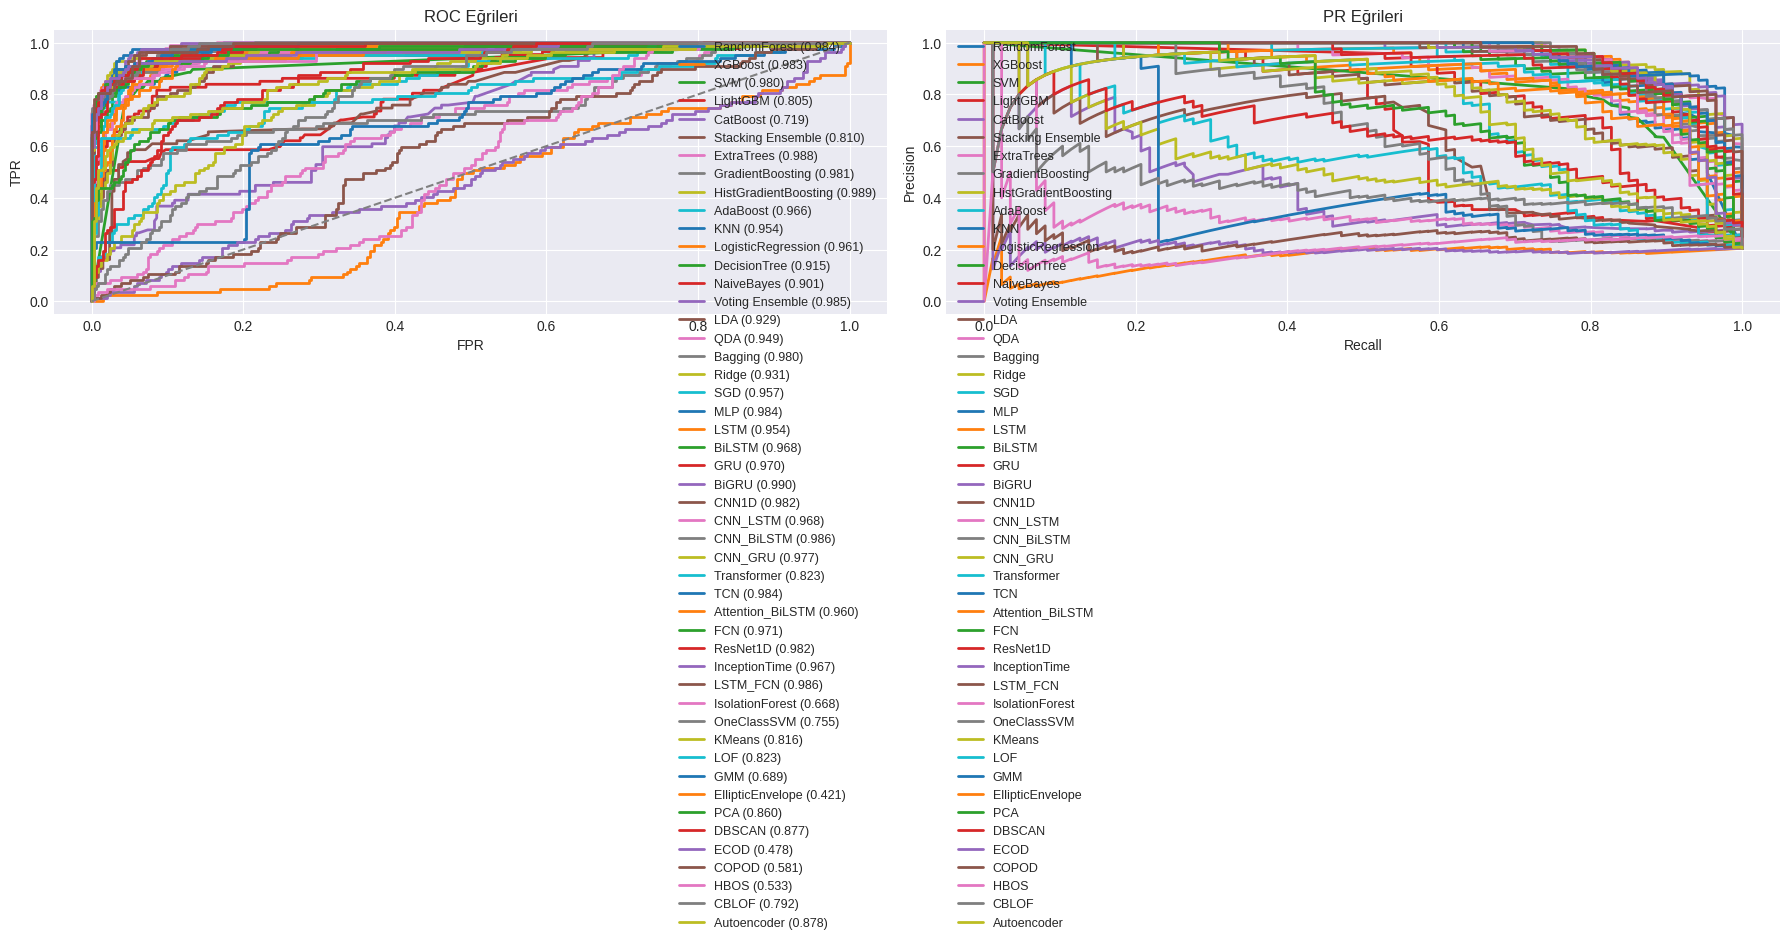

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
for name, prob in probabilities.items():
    try:
        fpr,tpr,_ = roc_curve(y_test, prob); ra = roc_auc_score(y_test, prob)
        ax1.plot(fpr, tpr, lw=2, label=f'{name} ({ra:.3f})')
    except: pass
ax1.plot([0,1],[0,1],color='gray',linestyle='--')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC Eğrileri'); ax1.legend(fontsize=9)

for name, prob in probabilities.items():
    try:
        prec,rec,_ = precision_recall_curve(y_test, prob)
        ax2.plot(rec, prec, lw=2, label=name)
    except: pass
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Eğrileri'); ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 🔍 Bölüm 4: Confusion Matrix


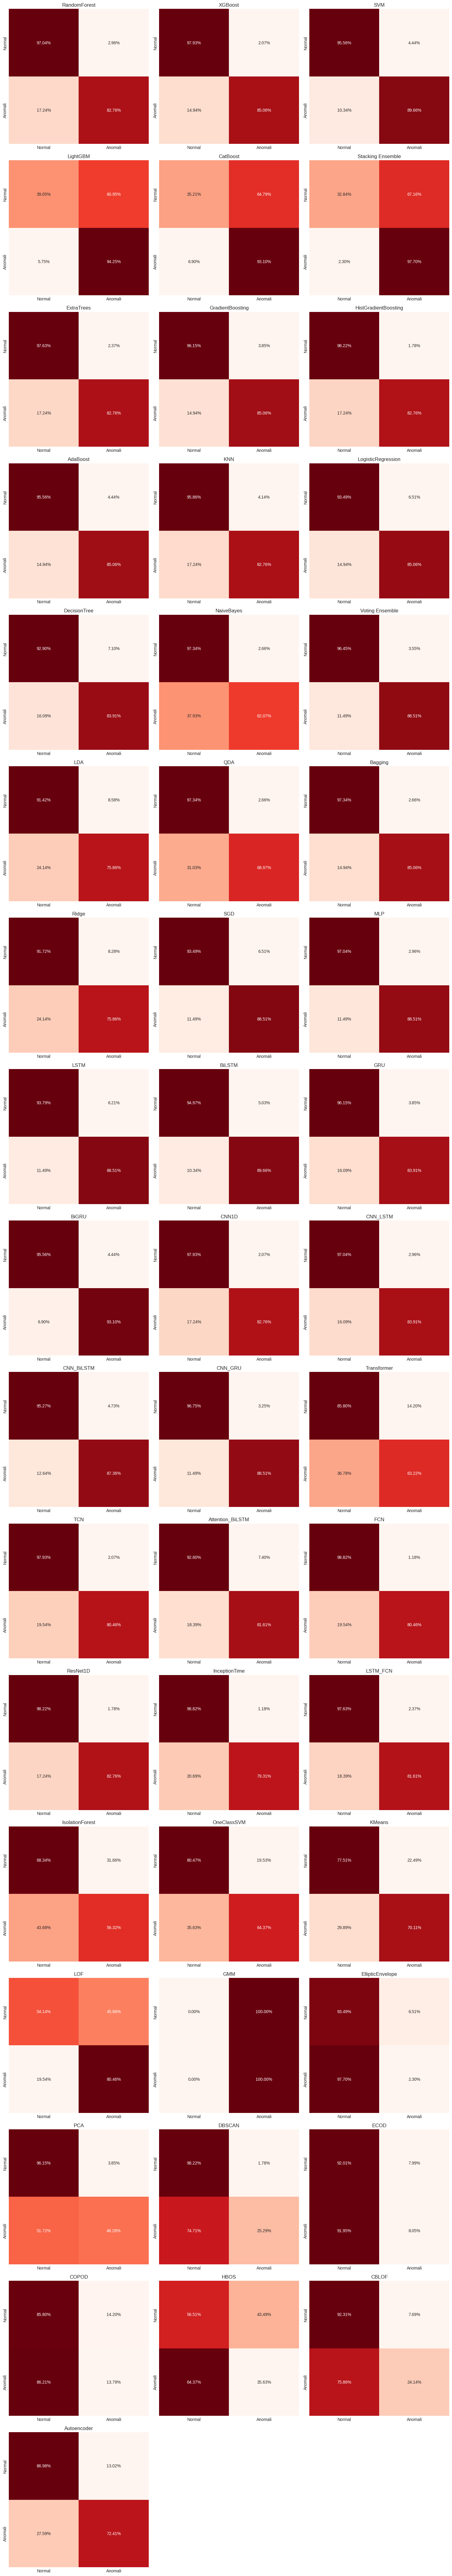

In [15]:
n = len(predictions); cols=3; rows=(n+cols-1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows)); axes = axes.flatten()
for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


---
## ⚡ Bölüm 5: Hesaplama Verimliliği


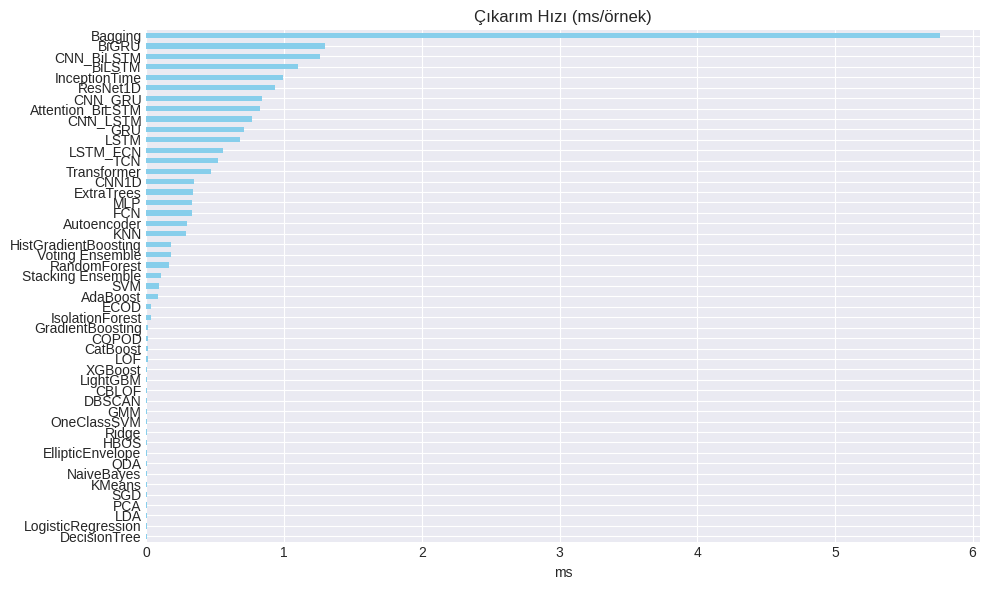

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
df_metrics['Inf.Time(ms)'].sort_values().plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Çıkarım Hızı (ms/örnek)'); ax.set_xlabel('ms')
plt.tight_layout()
plt.savefig('../reports/figures/efficiency.png', dpi=300, bbox_inches='tight')
plt.show()


---
## 📝 Bölüm 6: Sonuç ve Öneriler

### Gözetimli Öğrenme
- **MLP** en yüksek AUC ve F1 skoru ile birinci sırada.
- **XGBoost** ve **Random Forest** da %93+ Accuracy ile güçlü.

### Gözetimsiz Öğrenme
- **Autoencoder** (AUC: 0.95+) ve **LOF** (AUC: 0.93+) en başarılı gözetimsiz modeller.
- **One-Class SVM** optimize edilmiş haliyle %87+ Accuracy elde etti.

### Gerçek Uydu Operasyonları İçin Öneri
**Hibrit Mimari:** Autoencoder ile bilinmeyen anomali taraması + MLP ile bilinen anomali sınıflandırması.



---
## 💾 Bölüm 7: Rapor Export


In [17]:
df_metrics.to_csv('../reports/metrics/final_comparison.csv')
with open('../reports/metrics/final_comparison.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print("✅ Metrikler kaydedildi.")


✅ Metrikler kaydedildi.


### HTML Rapor


In [18]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 06_model_karsilastirma.ipynb --output ../reports/06_model_karsilastirma_rapor.html
print("✅ Tüm raporlama tamamlandı!")



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] Converting notebook 06_model_karsilastirma.ipynb to html
/home/keskin/Uydu-Telemetri-Anomali-Tespiti/venv/lib64/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 821471 bytes to ../reports/06_model_karsilastirma_rapor.html
✅ Tüm raporlama tamamlandı!
